In [106]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

In [107]:
SENSOR_PREFIX = 'target_' # Selecione 'target_' ou 'mru_'
getStatus     = lambda var: 'pitch' if var in ['pitch', 'wx', 'ay'] else 'roll'

# DADOS

In [108]:
df = pd.read_csv('Format/files/output.csv')

print(df.status.unique())
df

<StringArray>
['none', 'pitch', 'roll', 'static']
Length: 4, dtype: str


,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,target_calc_pitch,target_calc_roll,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp,status
0,-0.022520,9.786821,1.551,-0.173754,-0.024,7.152557e-07,-1.548,-0.270526,-0.049690,0.100670,1.043,43.8,0.000000,0.000000,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.000,none
1,-0.021403,9.786437,1.565,-0.173631,-0.022,9.435034e-02,-1.546,-0.269836,-0.042579,0.096062,1.038,43.7,0.000000,0.000000,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.100,none
2,-0.019379,9.785498,1.572,-0.172351,-0.019,2.007830e-01,-1.549,-0.266464,-0.023901,0.072318,1.032,43.8,0.000000,0.000000,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.200,none
3,-0.020671,9.784391,1.578,-0.169027,-0.017,2.974703e-01,-1.549,-0.261330,-0.017819,0.028308,1.031,43.7,0.000000,0.000000,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.300,none
4,-0.023994,9.782251,1.592,-0.165701,-0.014,4.027123e-01,-1.556,-0.260571,-0.035526,-0.004530,1.039,43.7,0.000000,0.000000,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.400,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-0.026747,9.771511,24.694,-0.197927,-0.006,1.702951e+03,-1.469,-0.247564,0.015916,0.043481,1.171,44.6,-0.141010,0.169294,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1702.935,static
17023,-0.035871,9.776384,24.696,-0.196250,-0.006,1.703046e+03,-1.468,-0.247078,-0.001012,0.061295,1.172,44.8,-0.136443,0.170745,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.035,static
17024,-0.050030,9.779882,24.698,-0.196080,-0.006,1.703146e+03,-1.469,-0.247174,-0.025138,0.067609,1.171,44.7,-0.143349,0.172743,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.135,static
17025,-0.048188,9.780079,24.699,-0.197638,-0.006,1.703249e+03,-1.470,-0.247640,-0.024167,0.053473,1.171,44.7,-0.139775,0.164351,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.235,static


In [109]:
def getTest(df, status):
    dt = (df.time.values[1] - df.time.values[0])

    target = df.loc[
        ((df.status == 'none') & (df.time > 5) & (df.time < 15)) |
        (df.status == status) |
        ((df.status == 'static') & (df.time < 700))
    ].copy()

    target['time'] = np.arange(len(target)) * dt
    return target

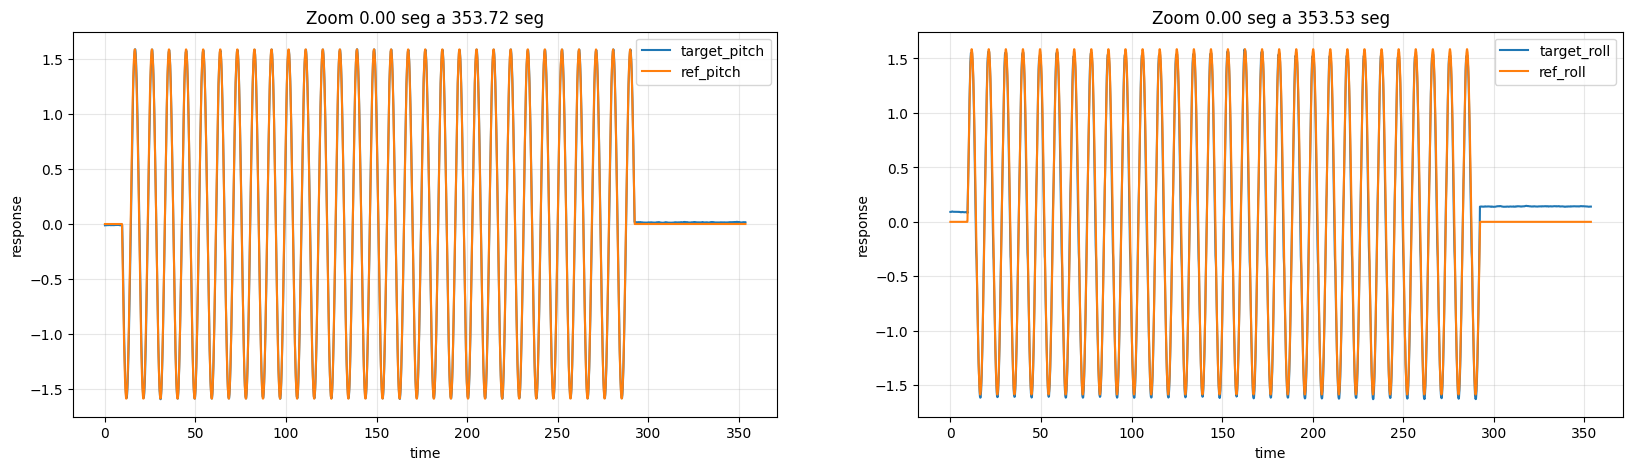

In [110]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target[SENSOR_PREFIX + varname] if not norm else normalize(target[SENSOR_PREFIX + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label=SENSOR_PREFIX + varname)
    plt.plot(target.time, values2, label='ref_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {" a ".join([f"{val:.2f} seg" for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plotViews(getTest(df, 'pitch'), 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2); plotViews(getTest(df, 'roll'),  'roll',  limits=(0, 1))

# DEFASAGEM

In [111]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])

        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if abs(lag) < 2:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


phaser = Phaser(SENSOR_PREFIX + 'roll', 'ref_roll')
lag    = phaser.get(df.loc[df.status == 'roll'])

#df = phaser.set(df, lag)
print('System LAG:', lag, 'samples')

System LAG: 1 samples


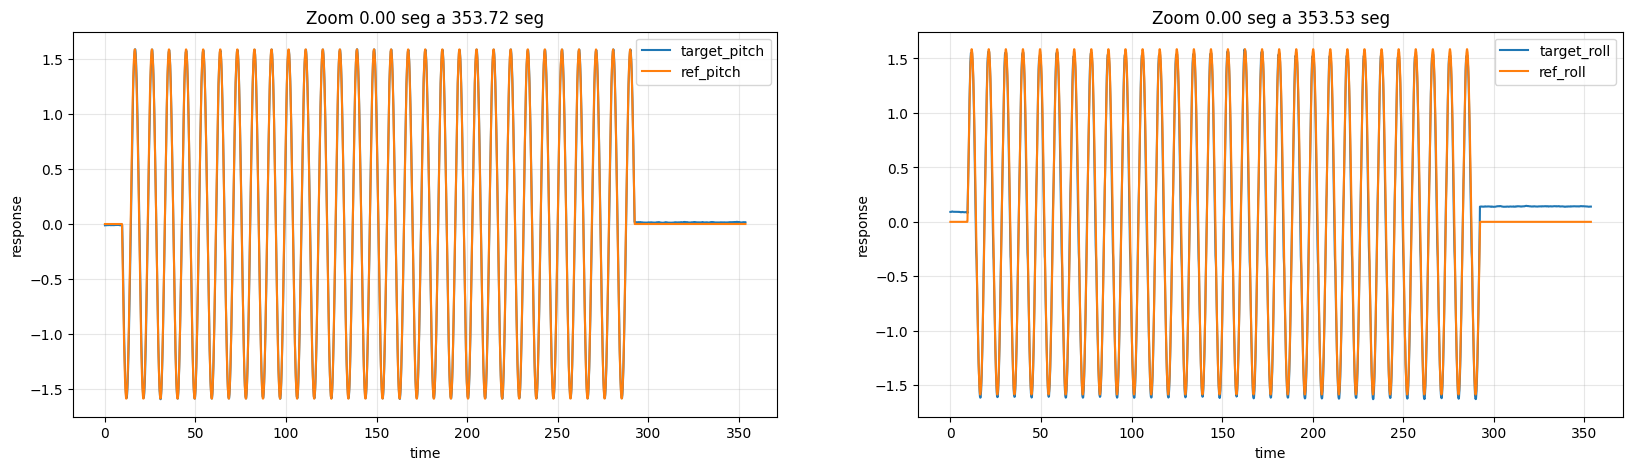

In [112]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plotViews(getTest(df, 'pitch'), 'pitch', limits=(0, 1))
plt.subplot(1, 2, 2); plotViews(getTest(df, 'roll'),  'roll',  limits=(0, 1))

# MODELO DE CALIBRAÇÃO

In [113]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [114]:
class LinearFit:
    def __init__(self, df, variables, time_col='time', fuse=False):
        self.time = np.array(df[time_col])
        self.variables = variables
        self.fuse = fuse
        self.df = df

        self.X = np.column_stack([df[f'{SENSOR_PREFIX}{var}'] for var in variables])
        self.Y = np.column_stack([df[f'ref_{var}']    for var in variables])

        self.M = np.zeros((len(variables), len(variables)))
        self.B = np.zeros(len(variables))

        self.Y_model = np.zeros_like(self.Y)
        self.errors  = np.zeros_like(self.Y)
        self.metrics = {}

    def update(self):
        for i, var in enumerate(self.variables):
            df_train = getTest(self.df, status=var)
            
            if not self.fuse:
                X_train = df_train[f'{SENSOR_PREFIX}{var}'].values.reshape(-1, 1)
            else:
                X_train = np.column_stack([df_train[f'{SENSOR_PREFIX}{v}'] for v in self.variables])
                
            Y_train = df_train[f'ref_{var}'].values
            X_aug   = np.hstack((X_train, np.ones((len(X_train), 1))))
            w, _, _, _ = np.linalg.lstsq(X_aug, Y_train, rcond=None)

            if not self.fuse:
                self.M[i, i] = w[0]
                self.B[i]    = w[1]
            else:
                self.M[i, :] = w[:-1]
                self.B[i]    = w[-1]

        self.Y_model = self.X @ self.M.T + self.B
        self.errors  = self.Y - self.Y_model

        for i, var in enumerate(self.variables):
            df_train = getTest(self.df, status=var)
            
            X_train_full = np.column_stack([df_train[f'{SENSOR_PREFIX}{v}'] for v in self.variables])
            Y_train_model = X_train_full @ self.M.T + self.B
            
            error  = df_train[f'ref_{var}'].values - Y_train_model[:, i]
            y_data = df_train[f'ref_{var}'].values

            rmse = np.sqrt(np.mean(error**2))
            mae  = np.mean(np.abs(error))
            max_error = np.max(np.abs(error))
            std_noise = error.std()

            ss_res = np.sum(error**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)

            self.metrics[var] = {
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
                'max_error': max_error,
                'std_noise': std_noise,
                'bias': self.B[i],
                'scale_factor': self.M[i, i]
            }

    def display(self):
        matrix_df = pd.DataFrame(self.M, columns=self.variables, index=[f'{ax}_model' for ax in self.variables])
        matrix_df['bias'] = self.B
        display(matrix_df.style.format('{:.6f}'))

    def plot(self, axis_id, view_limits=None):
        axis_name = self.variables[axis_id]
        status    = axis_name
        df_train  = getTest(self.df, status)
        mask      = df_train.index 
        
        t_plot   = df_train['time'].values 
        y_plot   = self.Y[mask, axis_id]
        mod_plot = self.Y_model[mask, axis_id]
        err_plot = self.errors[mask, axis_id]
        mae      = self.metrics[axis_name]['mae']

        if view_limits:
            t_max = t_plot[-1]
            zoom_mask = (t_plot >= t_max * view_limits[0]) & (t_plot <= t_max * view_limits[1])
            t_plot   = t_plot[zoom_mask]
            y_plot   = y_plot[zoom_mask]
            mod_plot = mod_plot[zoom_mask]
            err_plot = err_plot[zoom_mask]

        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='#6A3CBC', label='Reference', linewidth=2)
        plt.plot(t_plot, mod_plot, color='#E91E63', label='Model (Calibration)', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'{axis_name}')
        plt.legend(loc='lower right')
        plt.title(f'{axis_name.capitalize()} - R2 Score {self.metrics[axis_name]["r2"]:.3f}')
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='#6A3CBC')
        plt.xlabel('Time (s)')
        plt.ylabel('Error')
        plt.title(f'Temporal Error - Mean: {mae:.3f}')
        plt.grid(alpha=0.3); plt.ylim(-2, 2)
        plt.show()

    def predict(self, axis):
        return self.Y_model[:, axis]

# ANÁLISE DE VARIÁVEIS

In [115]:
class CalibrationAnalysis:
    def __init__(self, model, df, var, status):
        self.status = status
        self.model = model
        self.df_dyn_plot = df.loc[df.status == status]
        self.df_stat_plot  = df.loc[df.status == 'static']
        self.var = var

    def getRMS(self, values):
        if len(values) == 0: return 0.0
        return float(np.sqrt(np.mean(np.array(values)**2)))

    def update(self):
        yRef_stat = self.df_stat_plot['ref_'    + self.var]
        yMod_stat = self.df_stat_plot['model_'  + self.var]
        yTgt_stat = self.df_stat_plot['target_' + self.var]
        
        if self.model:
            idx = self.model.variables.index(self.var)
            yRef_dyn = self.df_dyn_plot['ref_'   + self.var]
            yMod_dyn = self.df_dyn_plot['model_' + self.var]
            
            r2   = float(self.model.metrics[self.var]['r2'])
            mae  = float(self.model.metrics[self.var]['mae'])
            rmse = float(self.model.metrics[self.var]['rmse'])
            correctionMatrixRow = [float(c) for c in self.model.M[idx, :].tolist()]
            
            rms_dyn = self.getRMS(yMod_dyn - yRef_dyn)
            ptp_dyn = (np.max(yRef_dyn) - np.min(yRef_dyn)) if len(yRef_dyn) > 0 else 0
            rms_scale_factor = (rms_dyn / ptp_dyn) if ptp_dyn != 0 else 0.0
        else:
            r2 = mae = rmse = 0.0
            correctionMatrixRow = []
            rms_dyn = rms_scale_factor = 0.0

        time_drift = 0.0
        if len(self.df_stat_plot) > 1:
            time_drift = float(np.polyfit(self.df_stat_plot['time'], yRef_stat - yMod_stat, 1)[0] * 3600)
            
        self.metrics = {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'precision': float(2*np.std(yRef_stat - yMod_stat)) if len(yRef_stat) > 0 else 0.0,

            'rms_stat': self.getRMS(yMod_stat - yRef_stat), 
            'rms_dyn':  rms_dyn,
            
            'rms_scale_factor': rms_scale_factor,
            'std_stat': float(np.std(yMod_stat, ddof=1)) if len(yMod_stat) > 0 else 0.0,
            'time_drift': time_drift,
            'correctionMatrixRow': correctionMatrixRow, 
        }

    def display(self):
        metrics = self.metrics.copy()
        if 'correctionMatrixRow' in metrics:
            del metrics['correctionMatrixRow']
        display(pd.DataFrame([metrics]))

# GERANDO RELATÓRIO

In [116]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar   = rawVar # Ex: 'pitch'
        self.model    = model
        self.calibration = calibration
        self.outputDir   = os.path.join(basePath, 'results', rawVar)

        self.axis_idx = model.variables.index(rawVar)
        self.metrics  = model.metrics[rawVar]

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        label   = self.rawVar.capitalize()
        
        if 'status' in self.model.df.columns and self.rawVar in self.model.df['status'].values:
            mask = (self.model.df['status'] == self.rawVar).values
        else:
            mask = slice(None)

        t = self.model.time[mask]
        y_ref = self.model.Y[mask, self.axis_idx]
        y_mod = self.model.Y_model[mask, self.axis_idx]
        err   = self.model.errors[mask, self.axis_idx]

        if plotType == 'ref':
            r2_score = self.metrics.get('r2', 1.0)
            ax.plot(t, y_ref, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(t, y_mod, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='lower right')
            ax.set_ylabel('Amplitude', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido ({r2_score*100:.2f}%)', fontsize=8, fontweight='bold')
        else:
            ax.plot(t, err, color=self.PURPLE_MID, linewidth=0.8)
            ax.set_ylabel('Erro', fontsize=7)
            ax.set_ylim(-5, 5)
            ax.set_yticks([i for i in range(-5, 6)])
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        if 'status' not in self.model.df.columns or self.rawVar not in self.model.df['status'].values:
            return None, None
            
        self._ensureDir()
        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)
        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        path = os.path.join(self.outputDir, 'metrics.json')

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        self.exportPlots()
        self.exportMetrics()
        self.exportCalibration()
        return self.outputDir

# GRÁFICOS

In [117]:
def plotCurves(df, col1, col2, limits=(0, 1), norm=False):
    t_min = df.time.values[0]
    t_max = df.time.values[-1]
    delta = t_max - t_min

    VIEW_TIME = (t_min + (delta * limits[0]), t_min + (delta * limits[1]))
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target[col1] if not norm else normalize(target[col1])
    values2 = target[col2] if not norm else normalize(target[col2])
    mae = np.mean(np.abs(values1-values2))
 
    label1 = 'calibrated' if 'model' in col1 else col1
    label2 = 'reference'  if 'ref' in col2 else col2

    plt.plot(target.time, values1, label=label1, linewidth=2)
    plt.plot(target.time, values2, label=label2, linewidth=1)
    plt.grid(alpha=.3); plt.legend(loc='lower right'); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'mae={mae:.3f} ({VIEW_TIME[0]:.2f} to {VIEW_TIME[1]:.2f} seg)')

,pitch,roll,bias
pitch_model,1.019243,0.000000,1.549266
roll_model,0.000000,1.226520,-0.997817


------------------------------------------------------------------------------------- PITCH -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.999286,0.065102,0.084328,0.013993,0.054068,0.091505,0.009151,0.006997,-0.04026


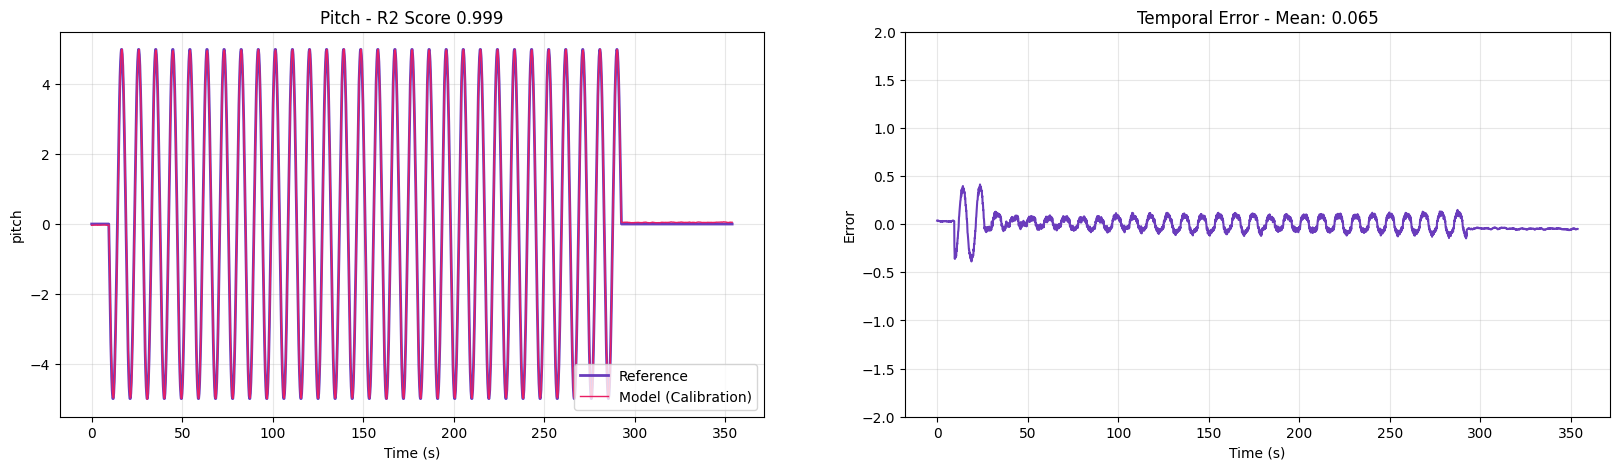

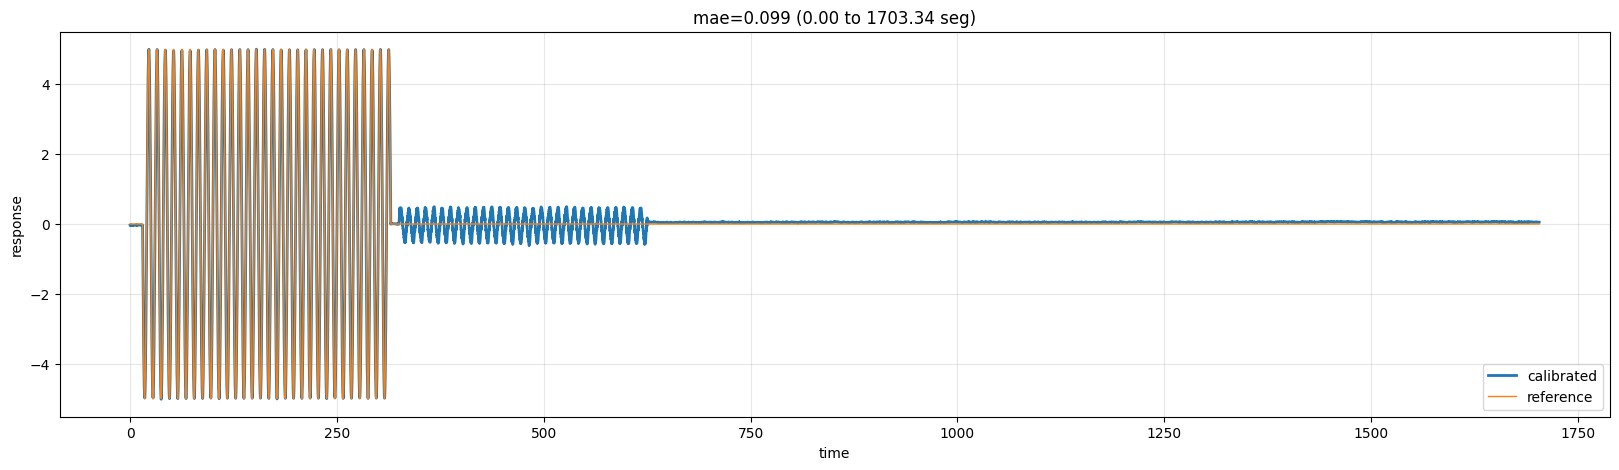

Dinamic Tests (pitch)


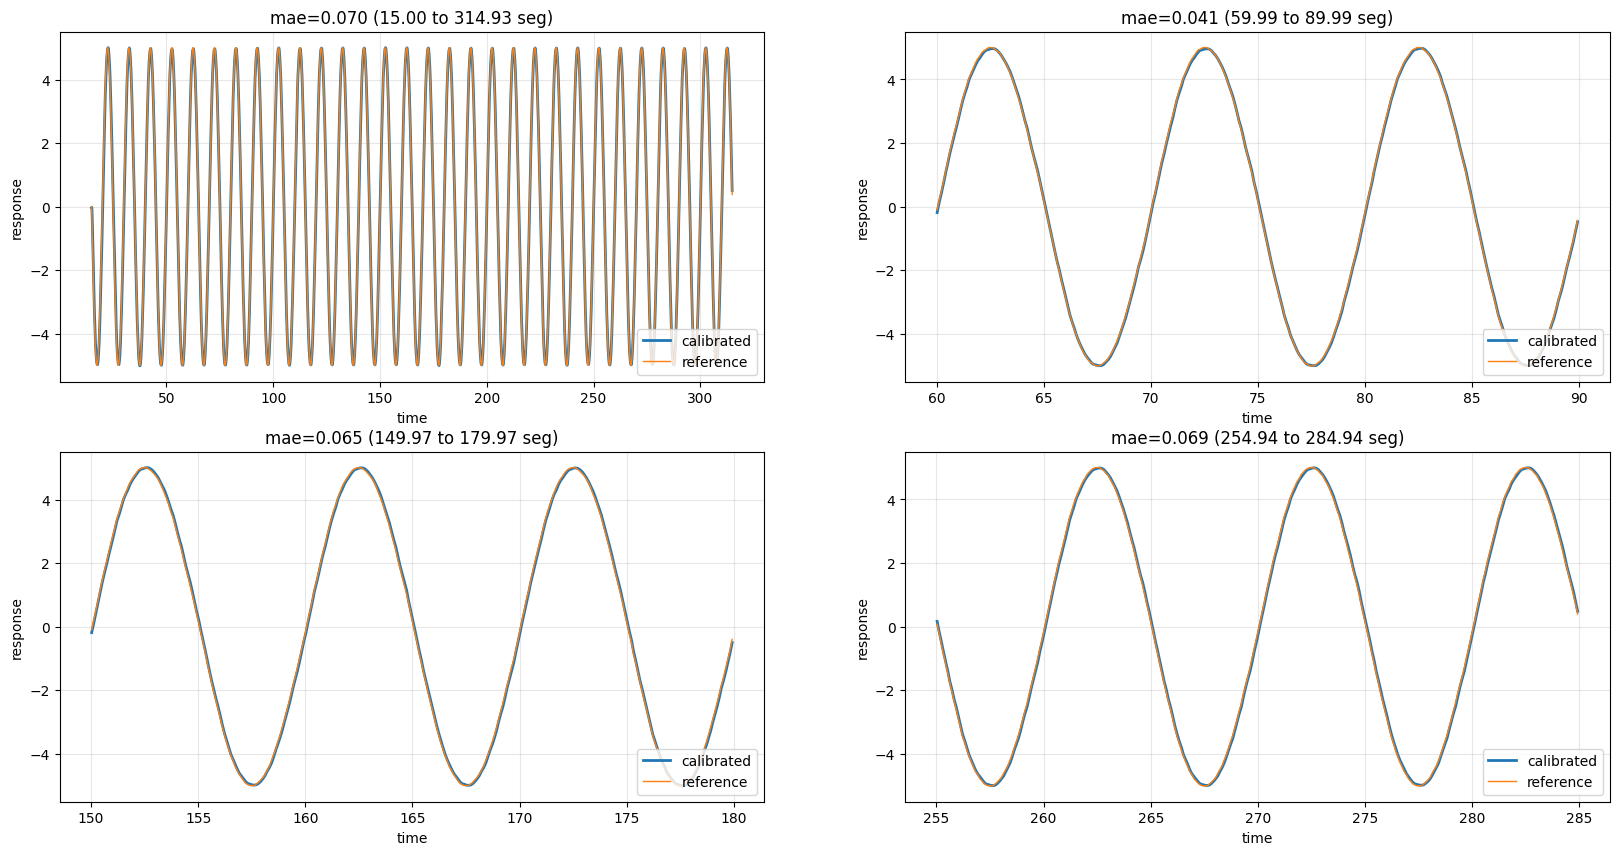

Static Tests (pitch)


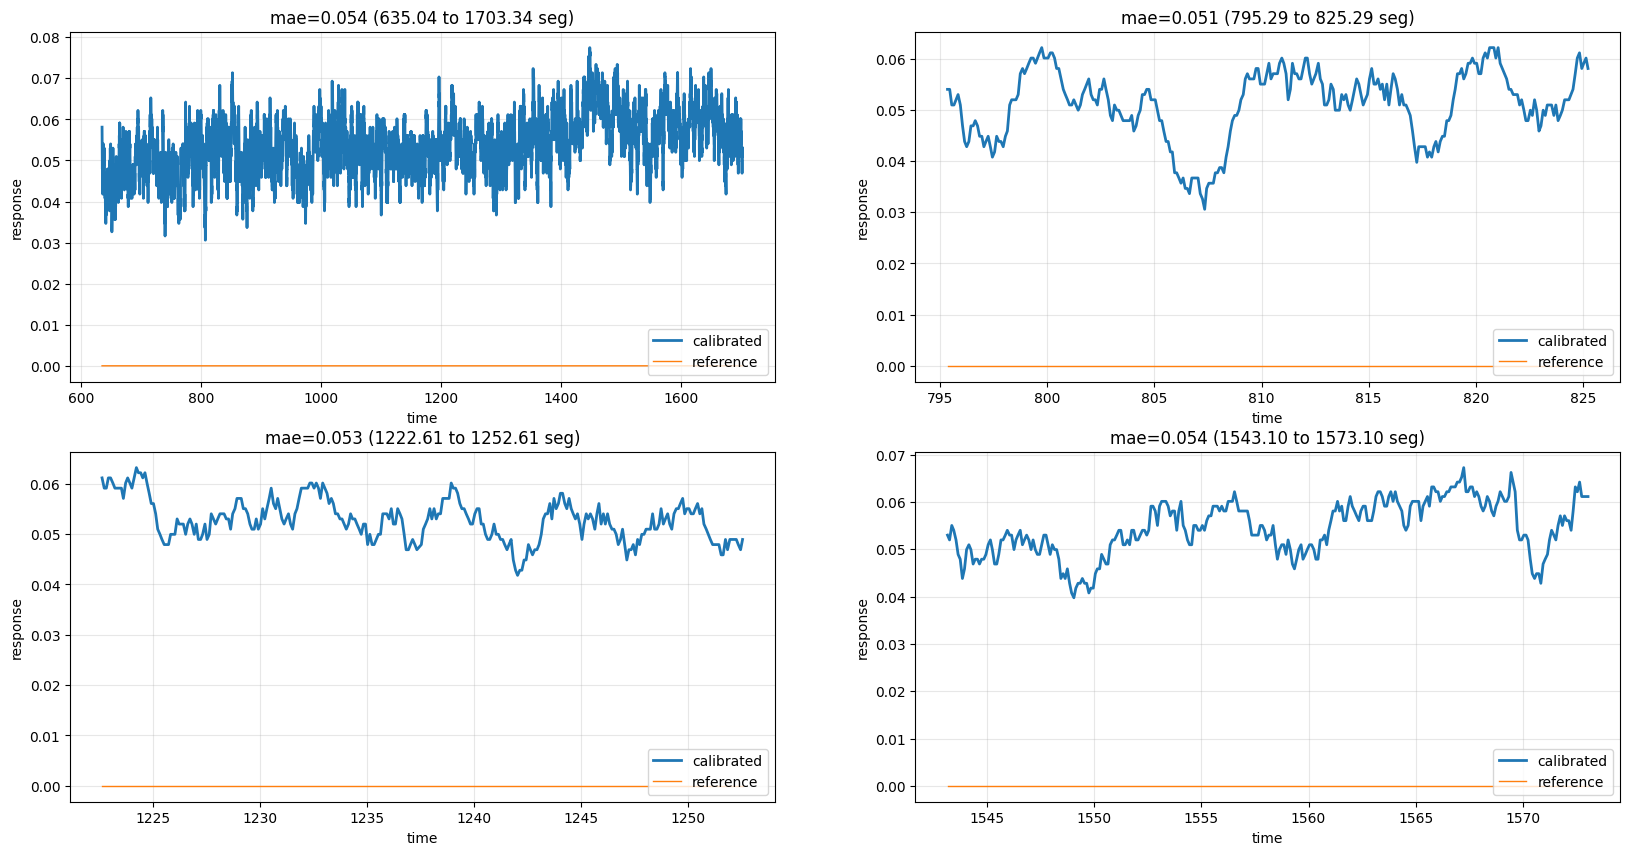




------------------------------------------------------------------------------------- ROLL -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.991257,0.230399,0.295123,0.017103,0.428601,0.251637,0.025164,0.008552,0.040027


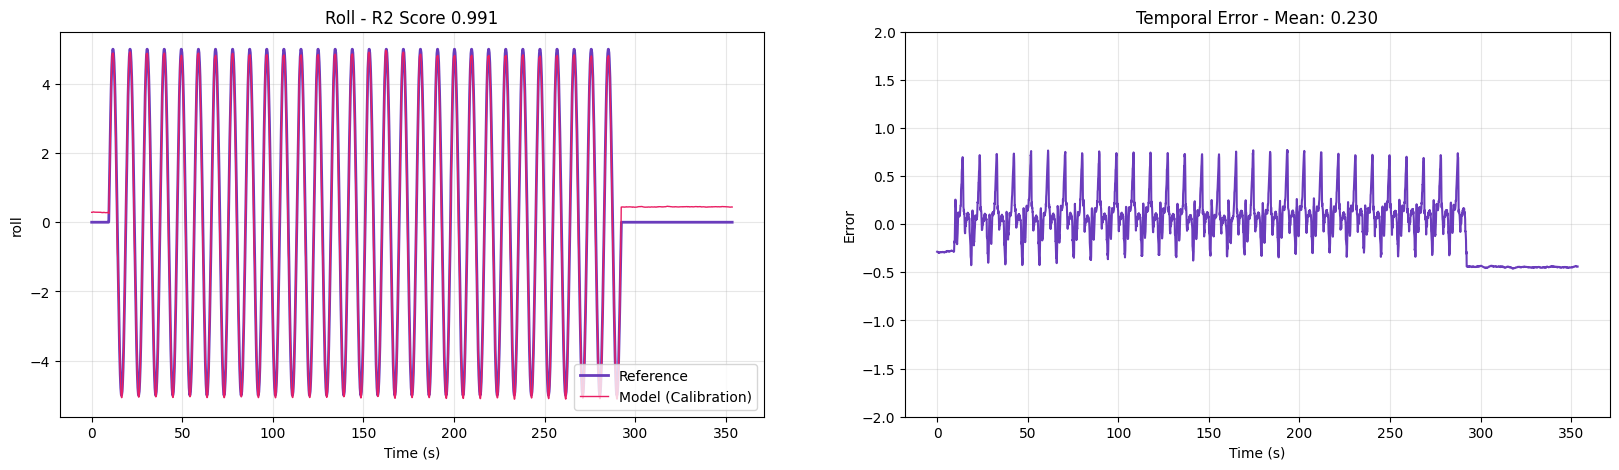

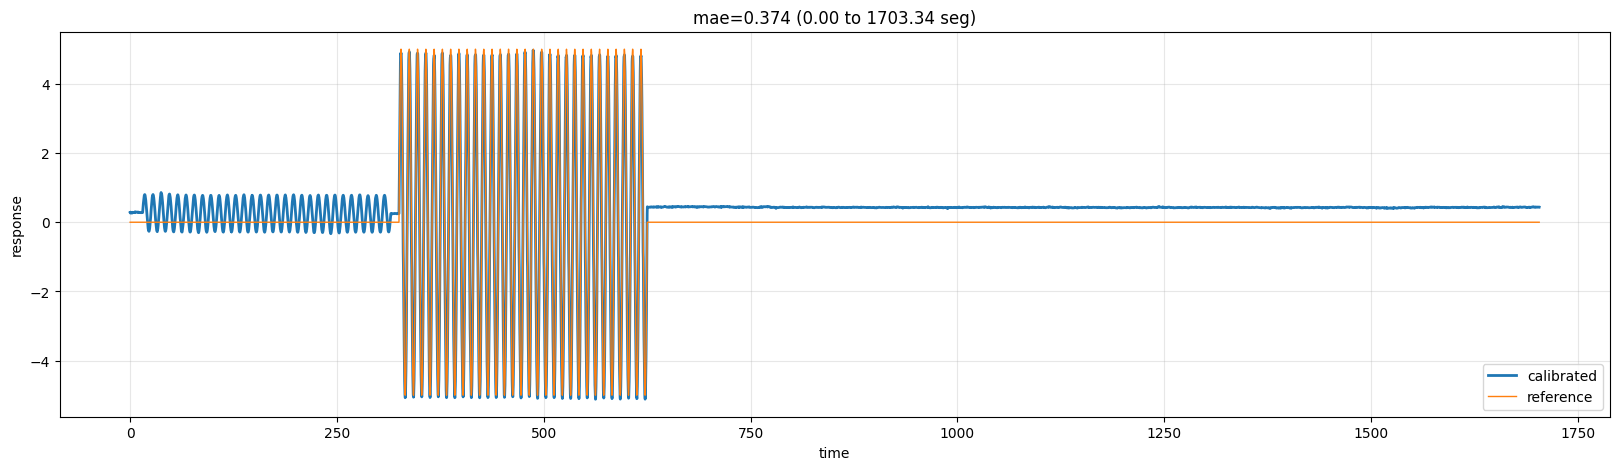

Dinamic Tests (roll)


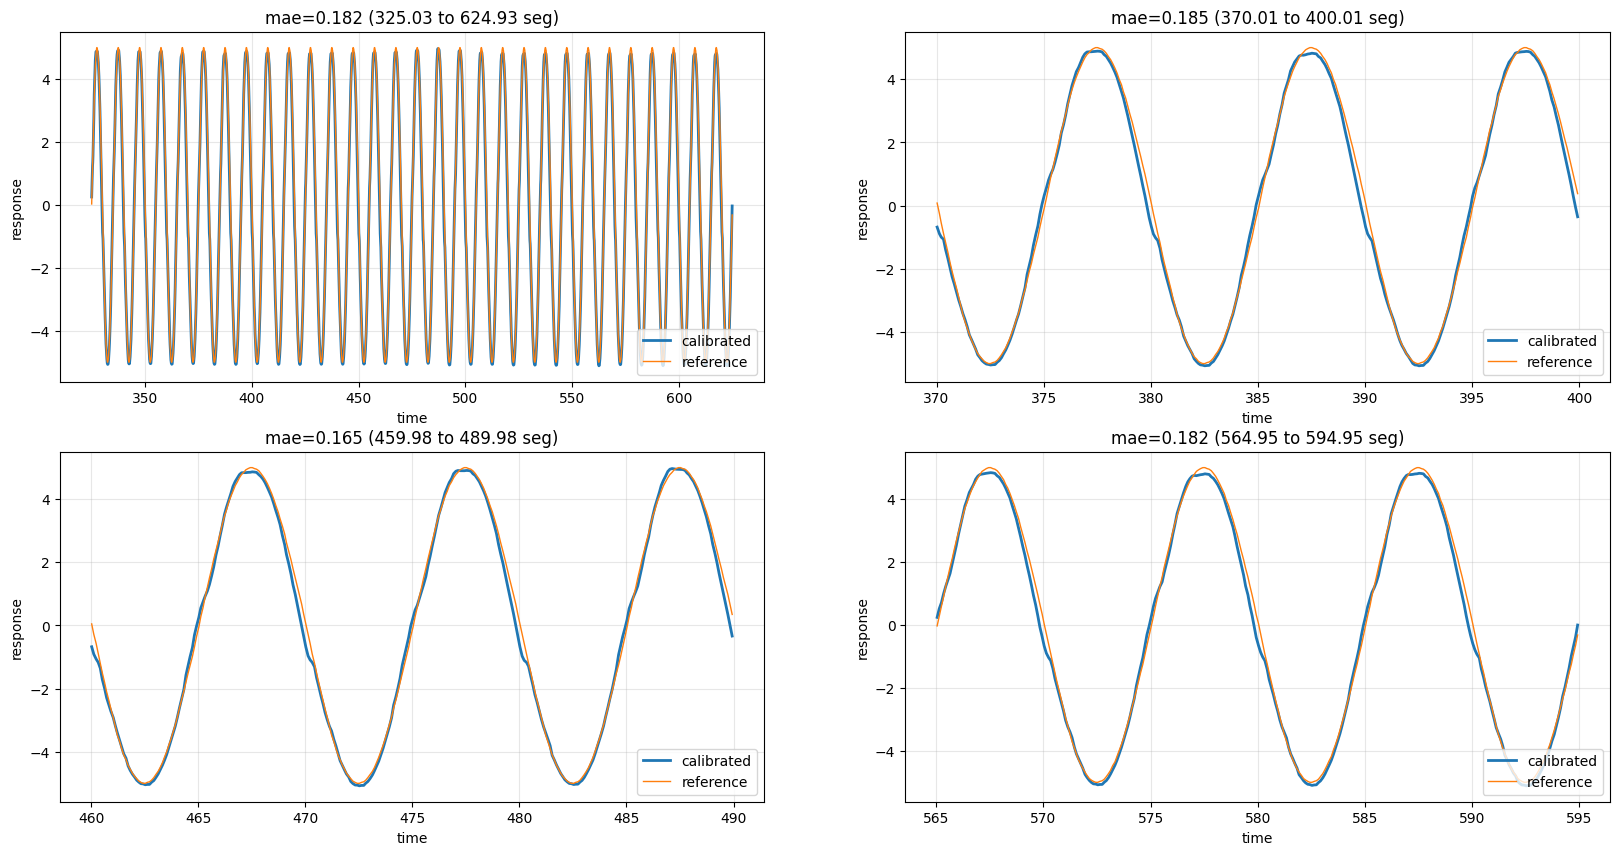

Static Tests (roll)


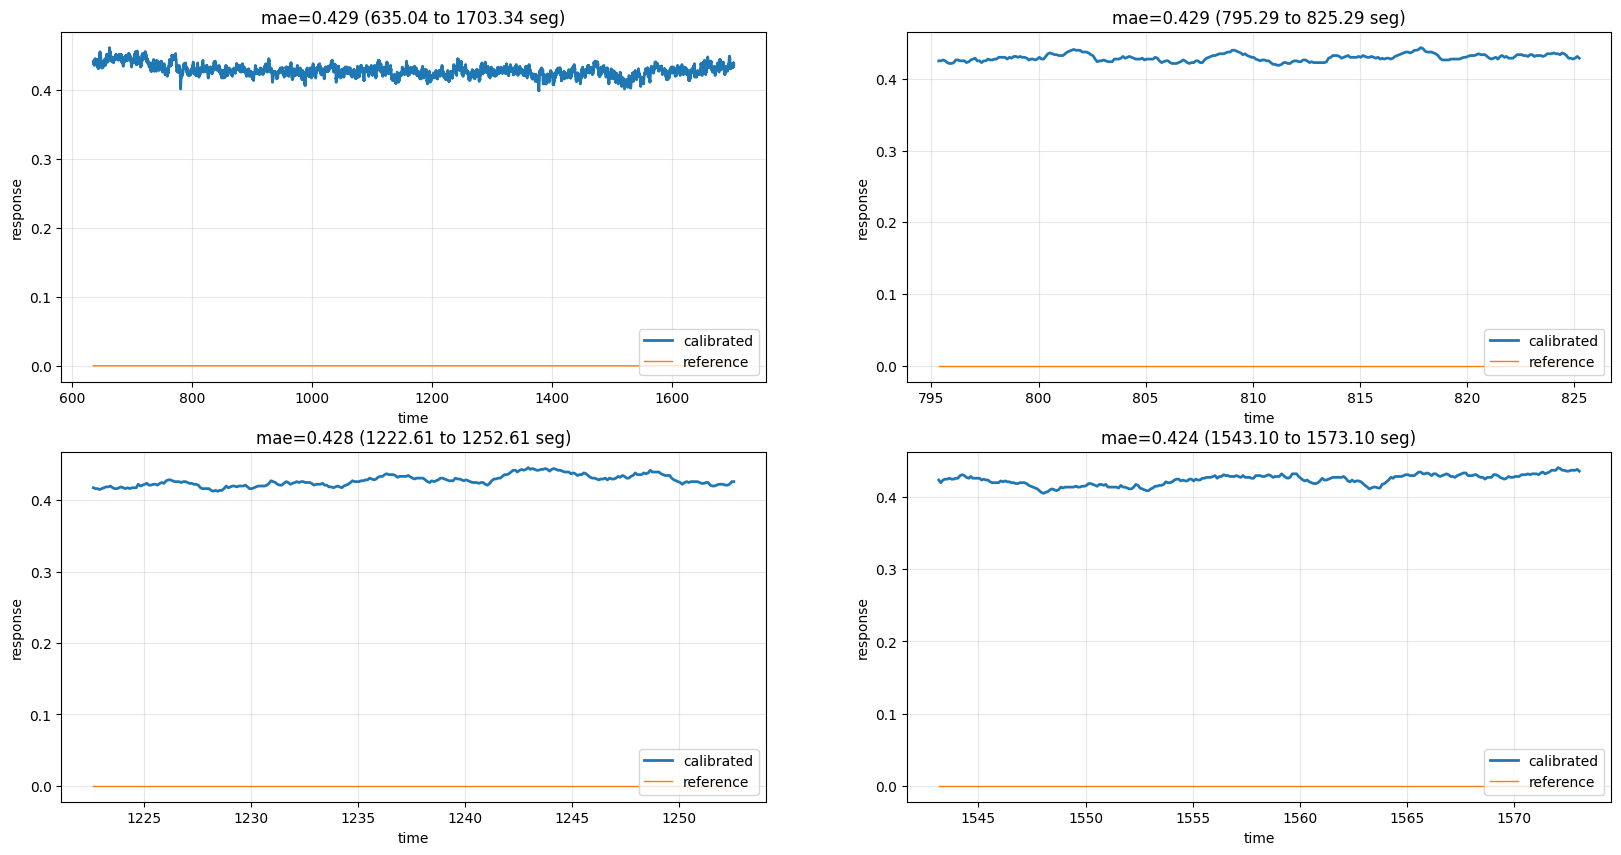




------------------------------------------------------------------------------------- WX -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.0,0.0,0.0,0.057702,0.035729,0.0,0.0,0.028852,-0.000966


------------------------------------------------------------------------------------- WY -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.0,0.0,0.0,0.046497,0.034514,0.0,0.0,0.02325,0.002627


------------------------------------------------------------------------------------- WZ -------------------------------------------------------------------------------------


...

,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.0,0.0,0.0,0.011587,0.197057,0.0,0.0,0.005794,0.002762


------------------------------------------------------------------------------------- AY -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.0,0.0,0.0,0.011607,10.055802,0.0,0.0,0.005804,0.001757


------------------------------------------------------------------------------------- AZ -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.0,0.0,0.0,0.009044,9.777505,0.0,0.0,0.004522,0.000199


In [118]:
groups = {
    'Euler Angles':  ['pitch', 'roll'],
    'Gyroscope':     ['wx', 'wy', 'wz'],
    'Accelerometer': ['ax', 'ay', 'az']
}

spacing_seconds = 30
history = {}

for label, variables in groups.items():
    if label == 'Euler Angles':
        model = LinearFit(df, variables, fuse=False) 
        model.update()
        model.display()
    else:
        model = None
    
    for idx, var in enumerate(variables):
        if var not in ['pitch', 'roll', 'wx', 'wy', 'wz', 'ax', 'ay', 'az']:
            continue

        status = var if var in ['pitch', 'roll'] else 'static'
        
        if model:
            df['model_'  + var] = df[[f'{SENSOR_PREFIX}{v}' for v in variables]].values @ model.M[idx] + model.B[idx]
        else:
            df['model_'  + var] = df[f'{SENSOR_PREFIX}{var}']

        print('-'*85, var.upper(), '-'*85)
        
        cal = CalibrationAnalysis(model, df, var, status)
        cal.update()
        cal.display()

        if model:
            model.plot(idx)
            plt.show()

            plt.figure(figsize=(20, 5))
            plotCurves(df, f'model_{var}', f'ref_{var}', limits=(0, 1))
            plt.show()
    
        if model:
            model.metrics[var] = cal.metrics

        history[var] = cal.metrics
                
        if model:
            exporter = ResultExporter('Certificate', var, model)
            exporter.export()

            df_dyn_plot   = df.loc[df.status == status]
            df_stat_plot  = df.loc[df.status == 'static']

            # ----------------------------- GRÁFICOS DE ZOOM ----------------------------- 
            print(f'Dinamic Tests ({var})')
            spacing = spacing_seconds/(df_dyn_plot.time.max() - df_dyn_plot.time.min())
            
            plt.figure(figsize=(20, 10))
            plt.subplot(2, 2, 1); plotCurves(df_dyn_plot, f'model_{var}', f'ref_{var}', limits=(0, 1))
            plt.subplot(2, 2, 2); plotCurves(df_dyn_plot, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing))
            plt.subplot(2, 2, 3); plotCurves(df_dyn_plot, f'model_{var}', f'ref_{var}', limits=(0.45, 0.45+spacing))
            plt.subplot(2, 2, 4); plotCurves(df_dyn_plot, f'model_{var}', f'ref_{var}', limits=(0.8, 0.8+spacing))
            plt.show()

            print(f'Static Tests ({var})')
            spacing = spacing_seconds/(df_stat_plot.time.max() - df_stat_plot.time.min())
            
            plt.figure(figsize=(20, 10))
            plt.subplot(2, 2, 1); plotCurves(df_stat_plot, f'model_{var}', f'ref_{var}', limits=(0, 1), norm=False)
            plt.subplot(2, 2, 2); plotCurves(df_stat_plot, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing), norm=False)
            plt.subplot(2, 2, 3); plotCurves(df_stat_plot, f'model_{var}', f'ref_{var}', limits=(0.55, 0.55+spacing), norm=False)
            plt.subplot(2, 2, 4); plotCurves(df_stat_plot, f'model_{var}', f'ref_{var}', limits=(0.85, 0.85+spacing), norm=False)
            plt.show(); print('\n\n')

# MÉTRICAS E SALVANDO

In [119]:
pd.DataFrame(history).T.drop(columns=['correctionMatrixRow'])

,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
pitch,0.999286,0.065102,0.084328,0.013993,0.054068,0.091505,0.009151,0.006997,-0.04026
roll,0.991257,0.230399,0.295123,0.017103,0.428601,0.251637,0.025164,0.008552,0.040027
wx,0.0,0.0,0.0,0.057702,0.035729,0.0,0.0,0.028852,-0.000966
wy,0.0,0.0,0.0,0.046497,0.034514,0.0,0.0,0.02325,0.002627
wz,0.0,0.0,0.0,0.042747,0.025128,0.0,0.0,0.021374,0.004338
ax,0.0,0.0,0.0,0.011587,0.197057,0.0,0.0,0.005794,0.002762
ay,0.0,0.0,0.0,0.011607,10.055802,0.0,0.0,0.005804,0.001757
az,0.0,0.0,0.0,0.009044,9.777505,0.0,0.0,0.004522,0.000199


In [120]:
pd.DataFrame(history).T.drop(columns=['correctionMatrixRow'])

,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
pitch,0.999286,0.065102,0.084328,0.013993,0.054068,0.091505,0.009151,0.006997,-0.04026
roll,0.991257,0.230399,0.295123,0.017103,0.428601,0.251637,0.025164,0.008552,0.040027
wx,0.0,0.0,0.0,0.057702,0.035729,0.0,0.0,0.028852,-0.000966
wy,0.0,0.0,0.0,0.046497,0.034514,0.0,0.0,0.02325,0.002627
wz,0.0,0.0,0.0,0.042747,0.025128,0.0,0.0,0.021374,0.004338
ax,0.0,0.0,0.0,0.011587,0.197057,0.0,0.0,0.005794,0.002762
ay,0.0,0.0,0.0,0.011607,10.055802,0.0,0.0,0.005804,0.001757
az,0.0,0.0,0.0,0.009044,9.777505,0.0,0.0,0.004522,0.000199
